# Boids Sweep — Compute-Method Performance Analysis

This notebook analyses the **boids general sweep** benchmark suite, which sweeps four compute backends
(JavaScript, Web Workers, WebAssembly, WebGPU) across **seven agent counts** (500 → 20 000).

Key dimensions explored:
- **Overall compute-time scaling** across all methods
- **Timing-phase breakdown** (setup, compute, readback, render)
- **Web Workers parallelism** (1 / 2 / 4 / 8 / 14 workers)
- **WebAssembly SIMD vs. scalar** modes
- **WebGPU bridge overhead** (host ↔ GPU transfer costs)
- **Frame-time variability** (p50, p95, p99 percentile tails)
- **Memory footprint** scaling

In [14]:
import sys, pathlib, importlib

# Ensure src/ is importable regardless of CWD
PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.constants as C
import src.plot_style as plot_style

# Reload local modules so notebook re-runs pick up edits
for mod in (C, plot_style):
    importlib.reload(mod)

from src.data_loader import load_benchmark_suite, runs_to_dataframe, frames_to_dataframe
from src.plot_style import apply_style, save_figure, get_method_color
from src.constants import METHOD_ORDER, METHOD_LABELS

In [15]:
# Choose palette: 0 = Academic, 1 = Teal
PALETTE = 1
apply_style(palette=PALETTE)

## 1 — Load Data

In [16]:
import pandas as pd
import numpy as np

BOIDS_JSON = PROJECT_ROOT / "raw-data" / "boids-general-sweep"

# Load the single boids benchmark suite
json_files = sorted(BOIDS_JSON.glob("*.json"))
assert len(json_files) >= 1, "No benchmark JSON found in boids-general-sweep/"

suite = load_benchmark_suite(json_files[0])
df = runs_to_dataframe(suite, suite_name="boids-general-sweep")
fdf = frames_to_dataframe(suite, suite_name="boids-general-sweep")

print(f"Loaded {len(df)} runs  |  {len(fdf)} frame records")
print(f"Methods: {df['method'].unique().tolist()}")
print(f"Agent counts: {sorted(df['agentCount'].unique())}")
df.head()

Loaded 70 runs  |  7000 frame records
Methods: ['WebWorkers', 'JavaScript', 'WebGPU', 'WebAssembly']
Agent counts: [np.int64(500), np.int64(1000), np.int64(2000), np.int64(4000), np.int64(8000), np.int64(10000), np.int64(20000)]


,suite,status,method,renderMode,agentCount,workerCount,wasmExecutionMode,executedFrames,durationMs,avgExecutionMs,...,avgTotalTime,avgCompileTime,compileEvents,frameTime_min,frameTime_max,frameTime_avg,frameTime_stdDev,frameTime_p50,frameTime_p95,frameTime_p99
0,boids-general-sweep,completed,WebWorkers,cpu,500,1.0,NaN,100,1376,3.770,...,3.770,0.3,1,1.8,24.4,3.770,4.032208,2.50,9.455,24.004
1,boids-general-sweep,completed,WebWorkers,cpu,500,2.0,NaN,100,1417,3.782,...,3.782,0.3,1,1.9,25.5,3.782,3.583110,2.70,9.505,23.520
2,boids-general-sweep,completed,WebWorkers,cpu,500,4.0,NaN,100,1390,5.506,...,5.506,0.3,1,2.4,31.2,5.506,6.937605,2.80,24.700,27.537
3,boids-general-sweep,completed,WebWorkers,cpu,500,8.0,NaN,100,1717,12.382,...,12.382,0.8,1,3.2,34.5,12.382,10.442743,6.95,30.595,33.114
4,boids-general-sweep,completed,WebWorkers,cpu,500,14.0,NaN,100,2744,20.426,...,20.426,1.5,1,4.7,44.2,20.426,10.271783,26.60,34.700,42.517


## 2 — Prepare Representative Data

For the all-methods comparison plots we pick a single representative per method × agent count:
- **WebWorkers** → best (lowest `avgComputeTime`) worker count
- **WebAssembly** → best WASM mode (scalar vs. SIMD)
- **WebGPU** → CPU-render row (compute is identical regardless of render mode)
- **JavaScript** → single entry

In [17]:
cpu_df = df[df["renderMode"] == "cpu"].copy()

# WebWorkers: keep best worker count per agent count
ww = cpu_df[cpu_df["method"] == "WebWorkers"]
best_ww = ww.loc[ww.groupby("agentCount")["avgComputeTime"].idxmin()]

# WebAssembly: keep best WASM mode per agent count
wa = cpu_df[cpu_df["method"] == "WebAssembly"]
best_wa = wa.loc[wa.groupby("agentCount")["avgComputeTime"].idxmin()]

# JavaScript & WebGPU — single rows per agent count
js = cpu_df[cpu_df["method"] == "JavaScript"]
gpu = cpu_df[cpu_df["method"] == "WebGPU"]

plot_df = pd.concat([js, best_ww, best_wa, gpu], ignore_index=True)
print(f"Representative rows: {len(plot_df)}")
plot_df[["method", "agentCount", "avgComputeTime", "workerCount", "wasmExecutionMode"]].head(10)

Representative rows: 28


,method,agentCount,avgComputeTime,workerCount,wasmExecutionMode
0,JavaScript,500,1.726,NaN,NaN
1,JavaScript,1000,4.019,NaN,NaN
2,JavaScript,2000,12.746,NaN,NaN
3,JavaScript,4000,44.025,NaN,NaN
4,JavaScript,8000,170.549,NaN,NaN
5,JavaScript,10000,264.886,NaN,NaN
6,JavaScript,20000,1044.983,NaN,NaN
7,WebWorkers,500,0.625,8.0,NaN
8,WebWorkers,1000,1.399,14.0,NaN
9,WebWorkers,2000,3.958,14.0,NaN


## 3 — Average Compute Time vs. Agent Count

  ✓ Saved outputs/figures/boids_compute_time_vs_agents.png
  ✓ Saved outputs/figures/boids_compute_time_vs_agents.pdf


[PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_compute_time_vs_agents.png'),
 PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_compute_time_vs_agents.pdf')]

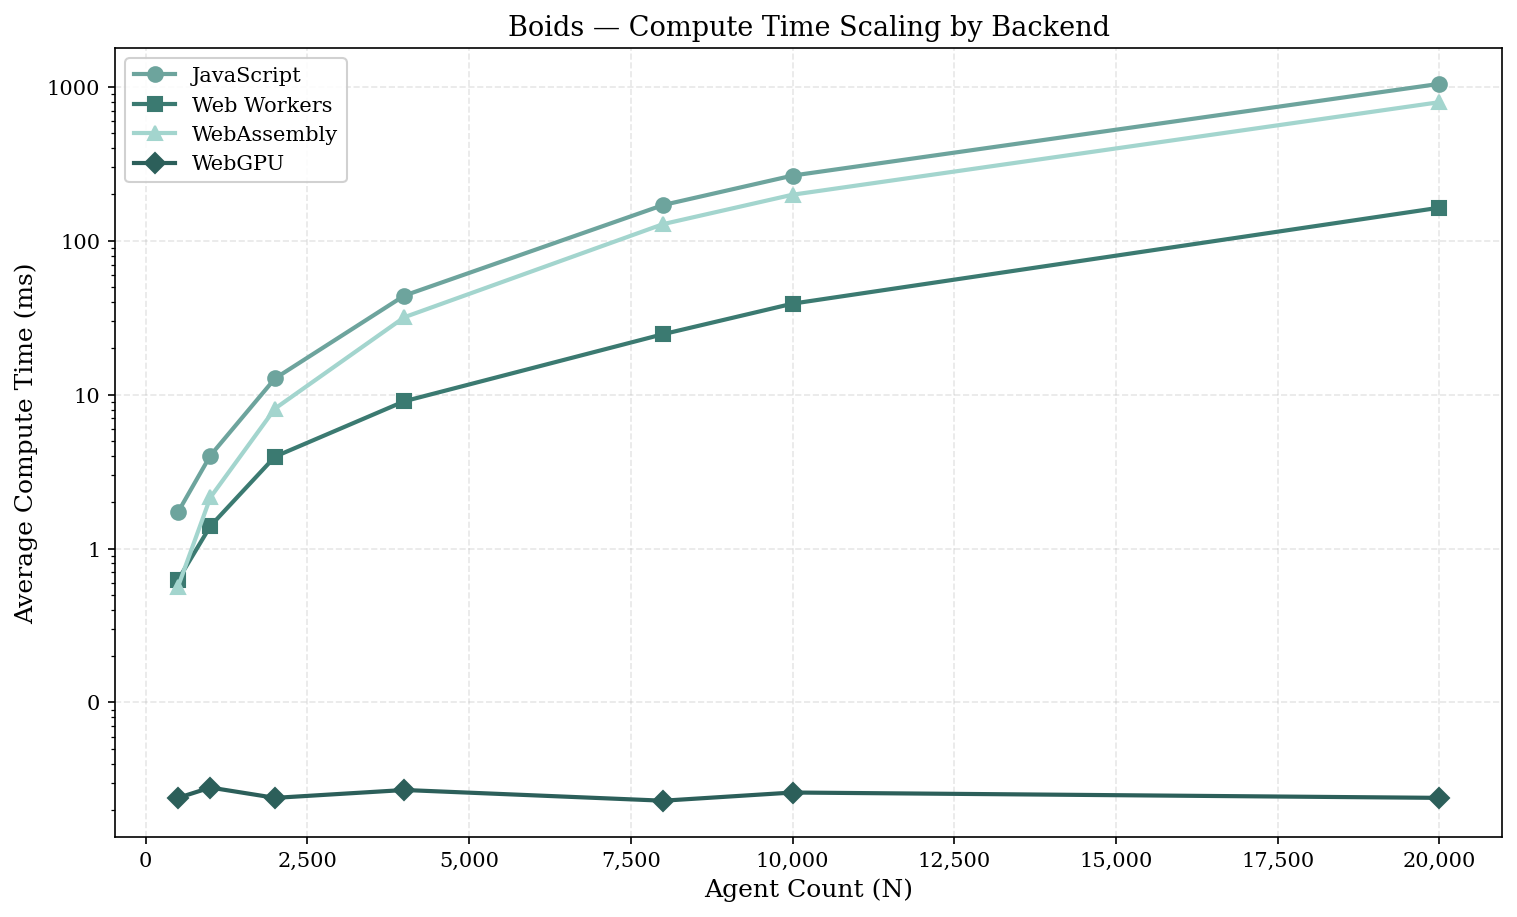

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))

markers = {"JavaScript": "o", "WebWorkers": "s", "WebAssembly": "^", "WebGPU": "D"}

for method in METHOD_ORDER:
    subset = plot_df[plot_df["method"] == method].sort_values("agentCount")
    ax.plot(
        subset["agentCount"],
        subset["avgComputeTime"],
        marker=markers.get(method, "o"),
        color=get_method_color(method),
        label=METHOD_LABELS.get(method, method),
    )

ax.set_yscale('log')  # Converts the y-axis to a base-10 logarithmic scale

# Optional: Clean up the formatting so you don't get scientific notation (10^1)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter()) # Hides messy sub-ticks

ax.set_xlabel("Agent Count (N)")
ax.set_ylabel("Average Compute Time (ms)")
ax.set_title("Boids — Compute Time Scaling by Backend")
ax.legend()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

save_figure(fig, "boids_compute_time_vs_agents")

## 4 — Timing-Phase Breakdown (Stacked Bars)

Break each backend's average frame time into **setup**, **compute**, **readback**, and **render** phases to show where time is spent.

  ✓ Saved outputs/figures/boids_timing_breakdown_stacked.png
  ✓ Saved outputs/figures/boids_timing_breakdown_stacked.pdf


[PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_timing_breakdown_stacked.png'),
 PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_timing_breakdown_stacked.pdf')]

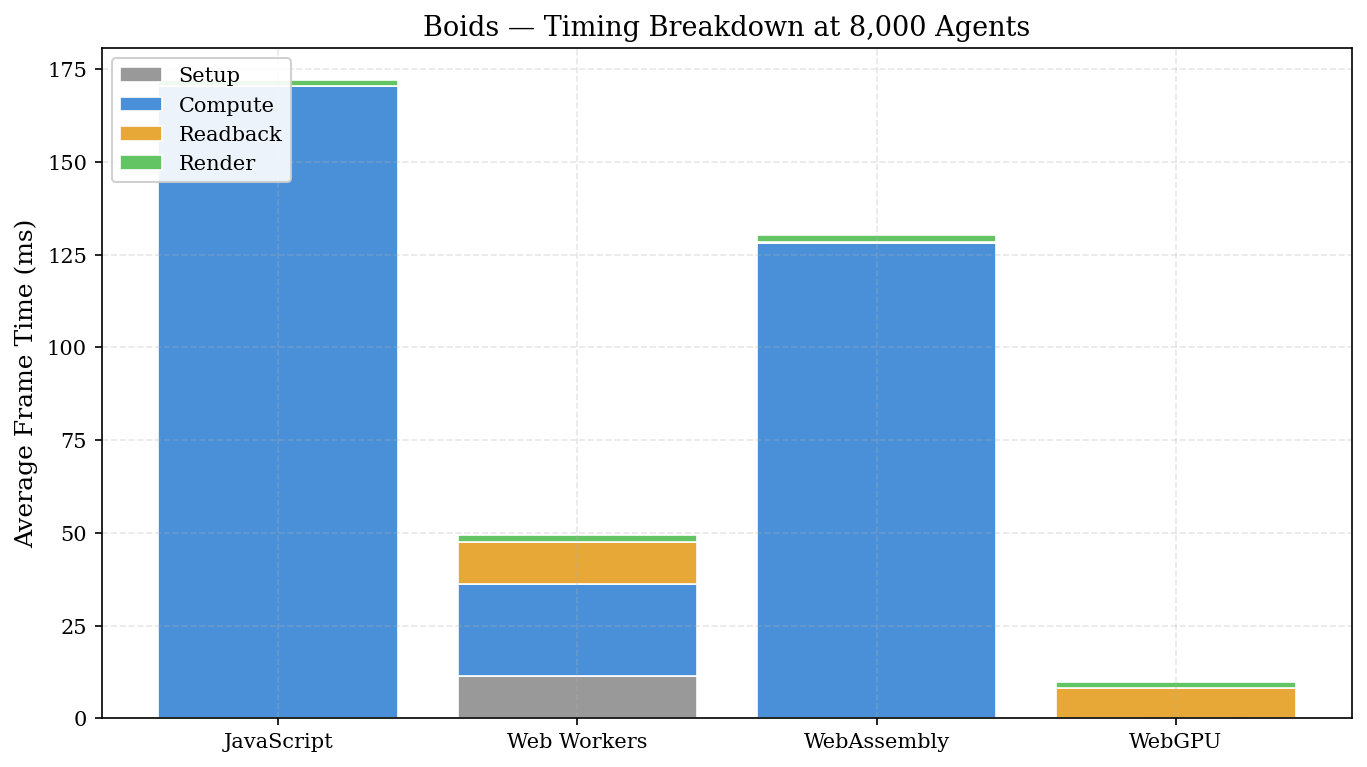

In [19]:
# Pick a mid-range agent count for the breakdown
BREAKDOWN_AGENTS = 8000

bd = plot_df[plot_df["agentCount"] == BREAKDOWN_AGENTS].copy()
bd = bd.set_index("method").reindex(METHOD_ORDER).dropna(subset=["avgComputeTime"])

phases = ["avgSetupTime", "avgComputeTime", "avgReadbackTime", "avgRenderTime"]
phase_labels = ["Setup", "Compute", "Readback", "Render"]
phase_colors = ["#999999", "#4A90D9", "#E8A838", "#62C462"]

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(bd))

for phase, label, color in zip(phases, phase_labels, phase_colors):
    vals = bd[phase].fillna(0).values
    ax.bar(
        [METHOD_LABELS.get(m, m) for m in bd.index],
        vals,
        bottom=bottom,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.8,
    )
    bottom += vals

ax.set_ylabel("Average Frame Time (ms)")
ax.set_title(f"Boids — Timing Breakdown at {BREAKDOWN_AGENTS:,} Agents")
ax.legend(loc="upper left")

save_figure(fig, "boids_timing_breakdown_stacked")

## 5 — Web Workers: Worker Count × Agent Count Heatmap

Explore how scaling the number of Web Workers affects compute time across different agent counts.

  ✓ Saved outputs/figures/boids_workers_heatmap.png
  ✓ Saved outputs/figures/boids_workers_heatmap.pdf


[PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_workers_heatmap.png'),
 PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_workers_heatmap.pdf')]

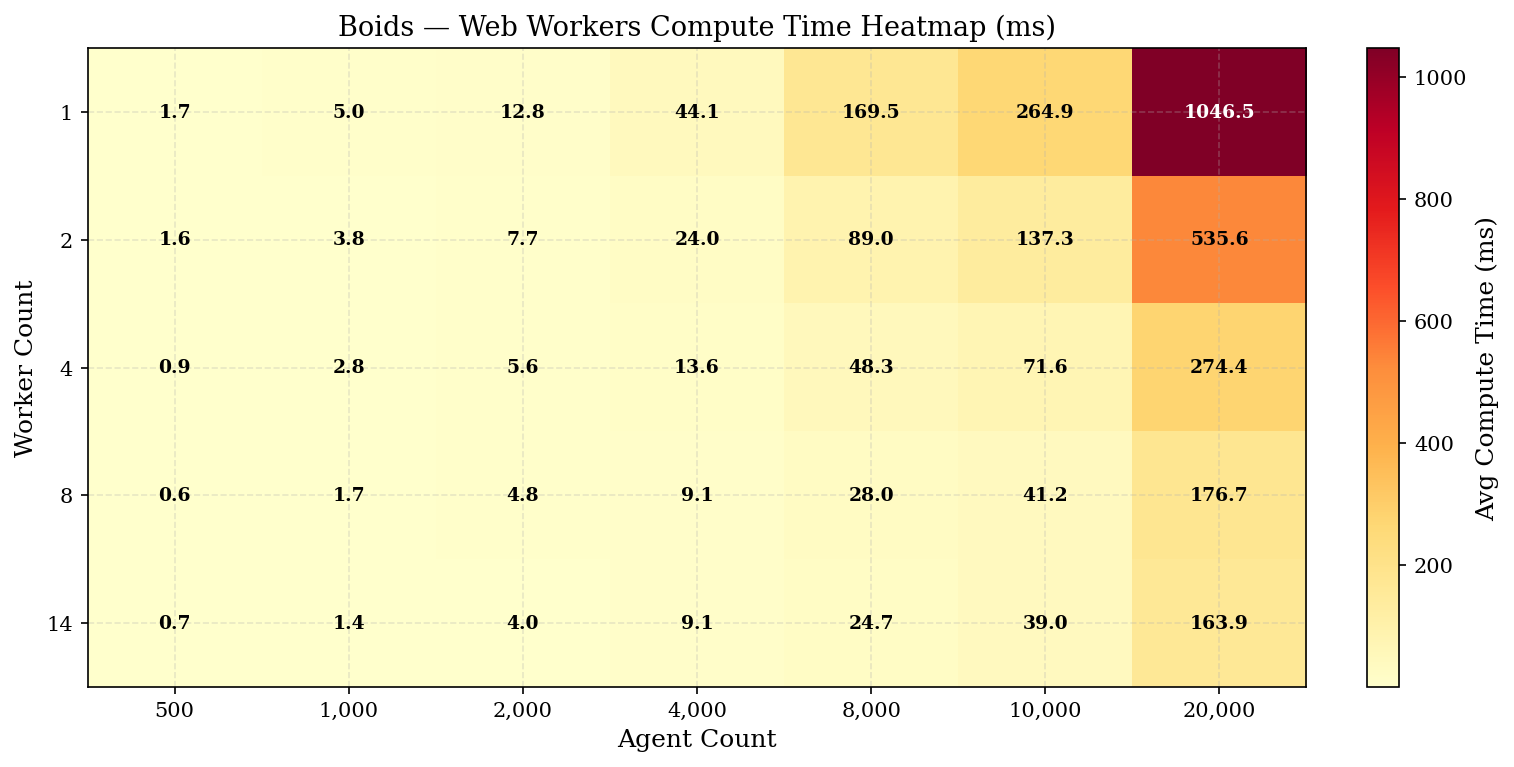

In [20]:
ww_all = cpu_df[cpu_df["method"] == "WebWorkers"].copy()
ww_pivot = ww_all.pivot_table(
    index="workerCount", columns="agentCount", values="avgComputeTime"
)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(ww_pivot.values, aspect="auto", cmap="YlOrRd")

ax.set_xticks(range(len(ww_pivot.columns)))
ax.set_xticklabels([f"{int(c):,}" for c in ww_pivot.columns])
ax.set_yticks(range(len(ww_pivot.index)))
ax.set_yticklabels([f"{int(w)}" for w in ww_pivot.index])
ax.set_xlabel("Agent Count")
ax.set_ylabel("Worker Count")
ax.set_title("Boids — Web Workers Compute Time Heatmap (ms)")

# Annotate cells with values
for i in range(len(ww_pivot.index)):
    for j in range(len(ww_pivot.columns)):
        val = ww_pivot.values[i, j]
        text_color = "white" if val > ww_pivot.values.max() * 0.6 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=9, color=text_color, fontweight="bold")

cbar = fig.colorbar(im, ax=ax, label="Avg Compute Time (ms)")

save_figure(fig, "boids_workers_heatmap")

## 6 — Web Workers: Parallel Speedup

Compute the speedup of multi-worker configurations relative to the single-worker (1w) baseline.

  ✓ Saved outputs/figures/boids_workers_speedup.png
  ✓ Saved outputs/figures/boids_workers_speedup.pdf


[PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_workers_speedup.png'),
 PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_workers_speedup.pdf')]

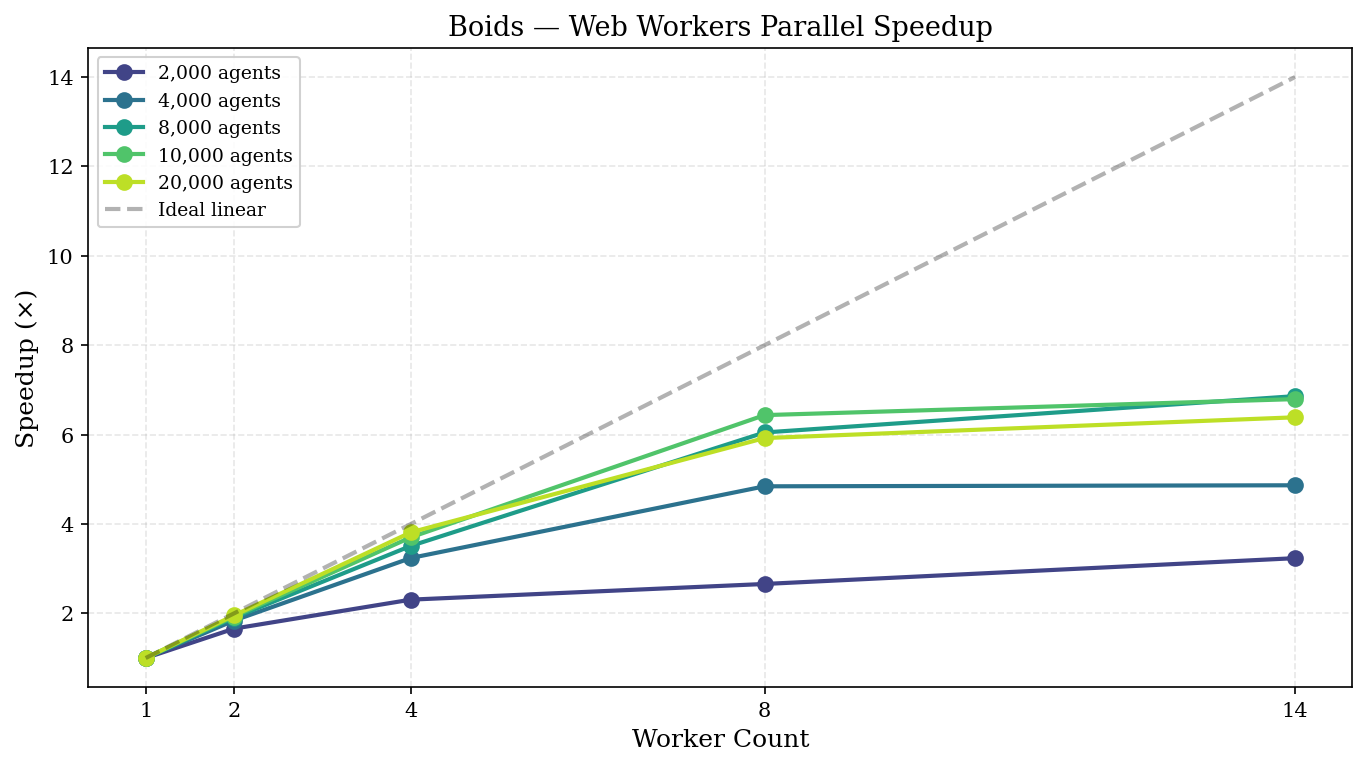

In [21]:
# Baseline: 1 worker
ww_1w = ww_all[ww_all["workerCount"] == 1].set_index("agentCount")["avgComputeTime"]

# Only plot agent counts where multi-worker actually helps (>= 2000)
high_agent_counts = sorted(ww_all[ww_all["agentCount"] >= 2000]["agentCount"].unique())

fig, ax = plt.subplots(figsize=(9, 5))
worker_counts = sorted(ww_all["workerCount"].unique())
cmap = plt.cm.viridis(np.linspace(0.2, 0.9, len(high_agent_counts)))

for idx, ac in enumerate(high_agent_counts):
    subset = ww_all[ww_all["agentCount"] == ac].sort_values("workerCount")
    baseline = ww_1w.get(ac, np.nan)
    speedup = baseline / subset["avgComputeTime"].values
    ax.plot(subset["workerCount"], speedup, marker="o",
            color=cmap[idx], label=f"{ac:,} agents", linewidth=2)

# Ideal linear speedup reference
ax.plot(worker_counts, worker_counts, "k--", alpha=0.3, label="Ideal linear")

ax.set_xlabel("Worker Count")
ax.set_ylabel("Speedup (×)")
ax.set_title("Boids — Web Workers Parallel Speedup")
ax.legend(fontsize=9)
ax.set_xticks(worker_counts)

save_figure(fig, "boids_workers_speedup")

## 7 — WebAssembly: Scalar vs. SIMD

  ✓ Saved outputs/figures/boids_wasm_scalar_vs_simd.png
  ✓ Saved outputs/figures/boids_wasm_scalar_vs_simd.pdf


[PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_wasm_scalar_vs_simd.png'),
 PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_wasm_scalar_vs_simd.pdf')]

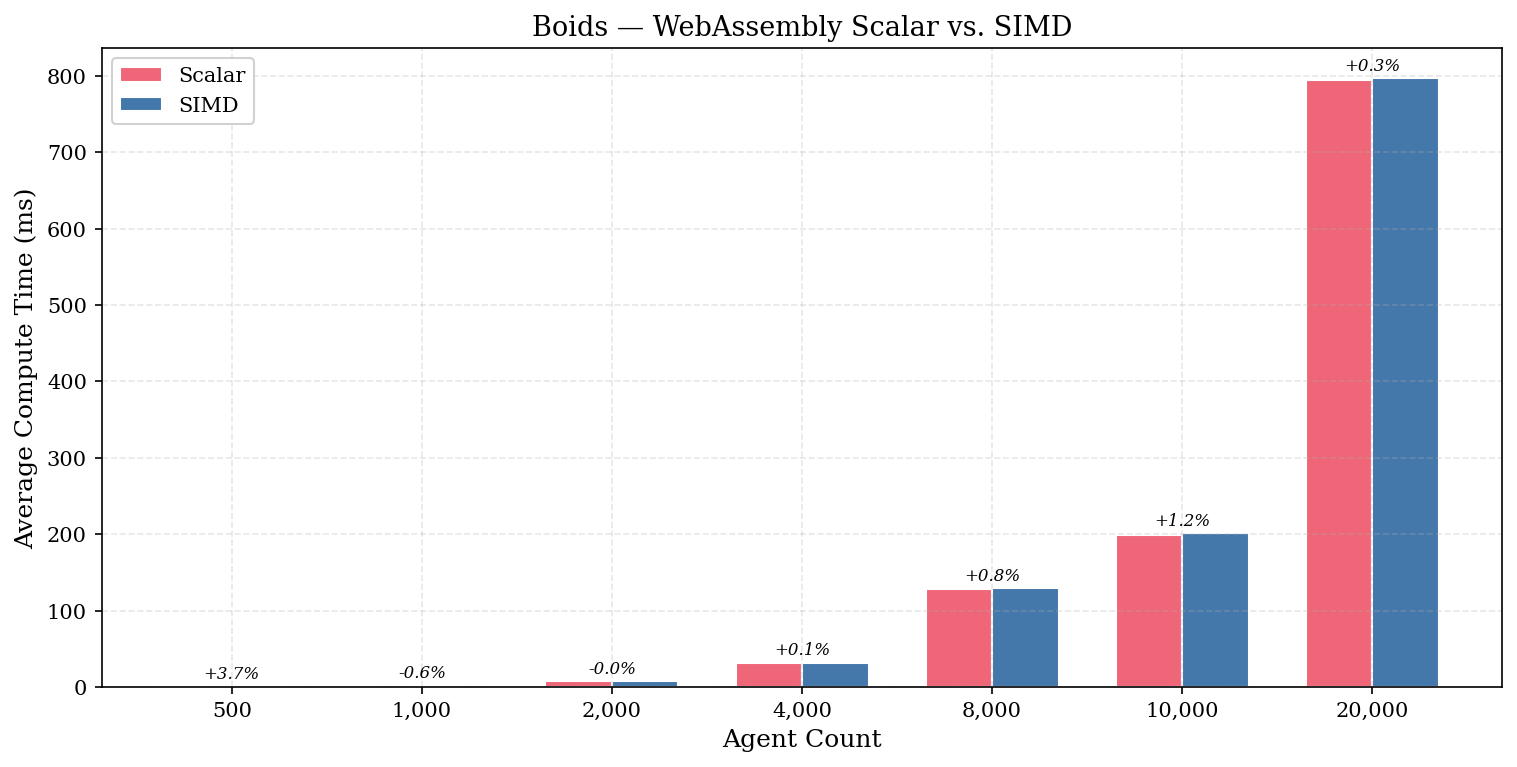

In [22]:
wasm_df = cpu_df[cpu_df["method"] == "WebAssembly"].copy()
agent_counts = sorted(wasm_df["agentCount"].unique())

scalar = wasm_df[wasm_df["wasmExecutionMode"] == "scalar"].sort_values("agentCount")
simd = wasm_df[wasm_df["wasmExecutionMode"] == "simd"].sort_values("agentCount")

x = np.arange(len(agent_counts))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, scalar["avgComputeTime"].values, width,
       label="Scalar", color="#EE6677", edgecolor="white")
ax.bar(x + width / 2, simd["avgComputeTime"].values, width,
       label="SIMD", color="#4477AA", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"{int(a):,}" for a in agent_counts])
ax.set_xlabel("Agent Count")
ax.set_ylabel("Average Compute Time (ms)")
ax.set_title("Boids — WebAssembly Scalar vs. SIMD")
ax.legend()

# Add percentage difference labels
for i, (s_val, simd_val) in enumerate(zip(scalar["avgComputeTime"].values, simd["avgComputeTime"].values)):
    pct = ((simd_val - s_val) / s_val) * 100
    sign = "+" if pct > 0 else ""
    ax.text(x[i], max(s_val, simd_val) + 5, f"{sign}{pct:.1f}%",
            ha="center", va="bottom", fontsize=8, fontstyle="italic")

save_figure(fig, "boids_wasm_scalar_vs_simd")

## 8 — WebGPU: Bridge-Overhead Breakdown

Analyse how much time WebGPU spends on host→GPU upload and GPU→host readback relative to the pure GPU compute time.

  ✓ Saved outputs/figures/boids_webgpu_bridge_breakdown.png
  ✓ Saved outputs/figures/boids_webgpu_bridge_breakdown.pdf


[PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_webgpu_bridge_breakdown.png'),
 PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_webgpu_bridge_breakdown.pdf')]

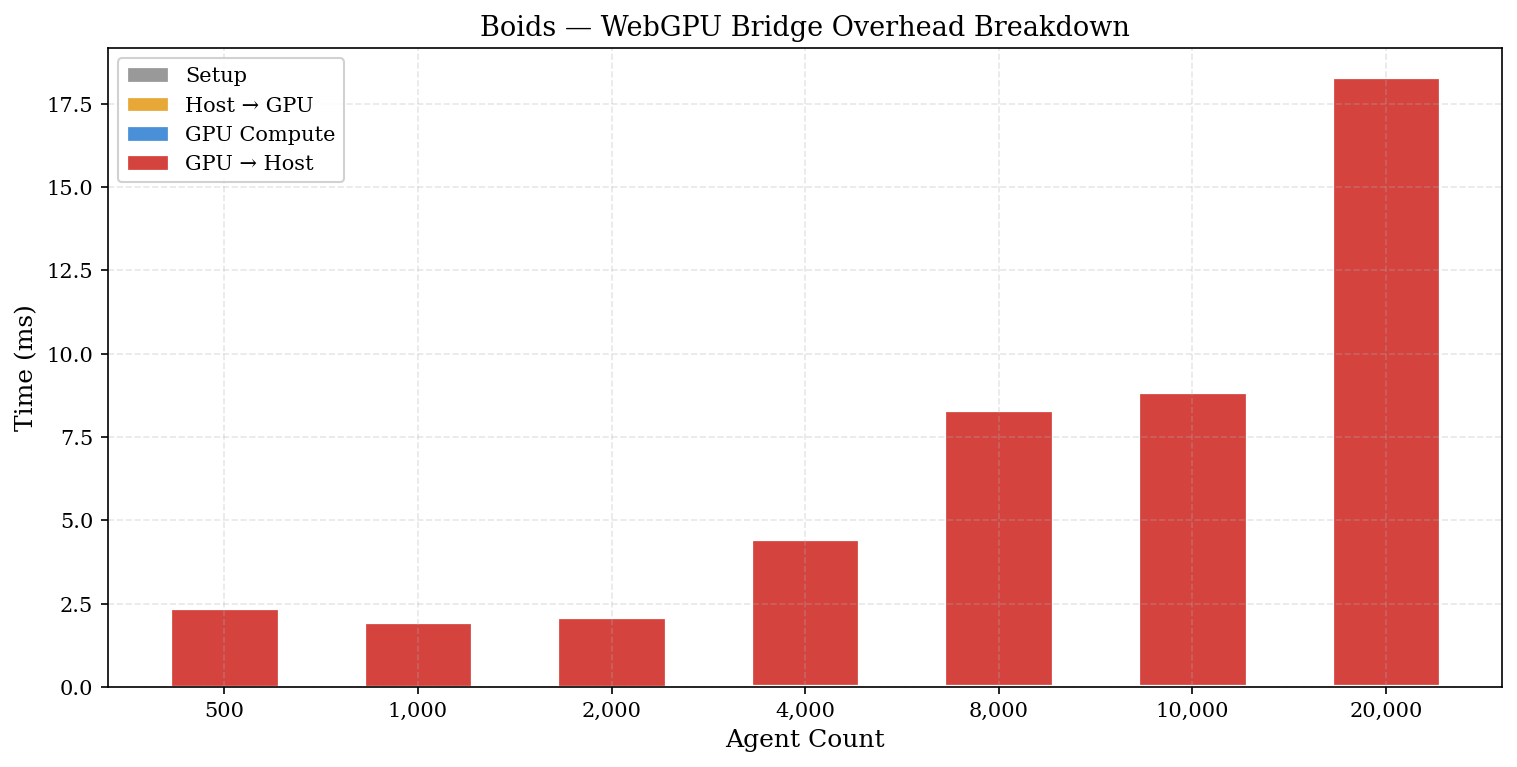

In [23]:
# Use frame-level data for WebGPU bridge analysis
gpu_frames = fdf[fdf["method"] == "WebGPU"].copy()

# Aggregate mean bridge timings per agent count (CPU-render only for fair comparison)
gpu_cpu = gpu_frames[gpu_frames["renderMode"] == "cpu"]
bridge_agg = gpu_cpu.groupby("agentCount").agg(
    hostToGpu=("hostToGpuTime", "mean"),
    gpuToHost=("gpuToHostTime", "mean"),
    compute=("computeTime", "mean"),
    setup=("setupTime", "mean"),
).reset_index().sort_values("agentCount")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(bridge_agg))
width = 0.55

components = [
    ("setup", "Setup", "#999999"),
    ("hostToGpu", "Host → GPU", "#E8A838"),
    ("compute", "GPU Compute", "#4A90D9"),
    ("gpuToHost", "GPU → Host", "#D5433E"),
]
bottom = np.zeros(len(bridge_agg))
for col, label, color in components:
    vals = bridge_agg[col].fillna(0).values
    ax.bar(x, vals, width, bottom=bottom, label=label, color=color, edgecolor="white", linewidth=0.6)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f"{int(a):,}" for a in bridge_agg["agentCount"]])
ax.set_xlabel("Agent Count")
ax.set_ylabel("Time (ms)")
ax.set_title("Boids — WebGPU Bridge Overhead Breakdown")
ax.legend(loc="upper left")

save_figure(fig, "boids_webgpu_bridge_breakdown")

## 9 — Frame-Time Variability (Percentile Tails)

Compare p50, p95, and p99 frame times to assess consistency and jitter risk for each backend.

  ✓ Saved outputs/figures/boids_frame_time_percentiles.png
  ✓ Saved outputs/figures/boids_frame_time_percentiles.pdf


[PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_frame_time_percentiles.png'),
 PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_frame_time_percentiles.pdf')]

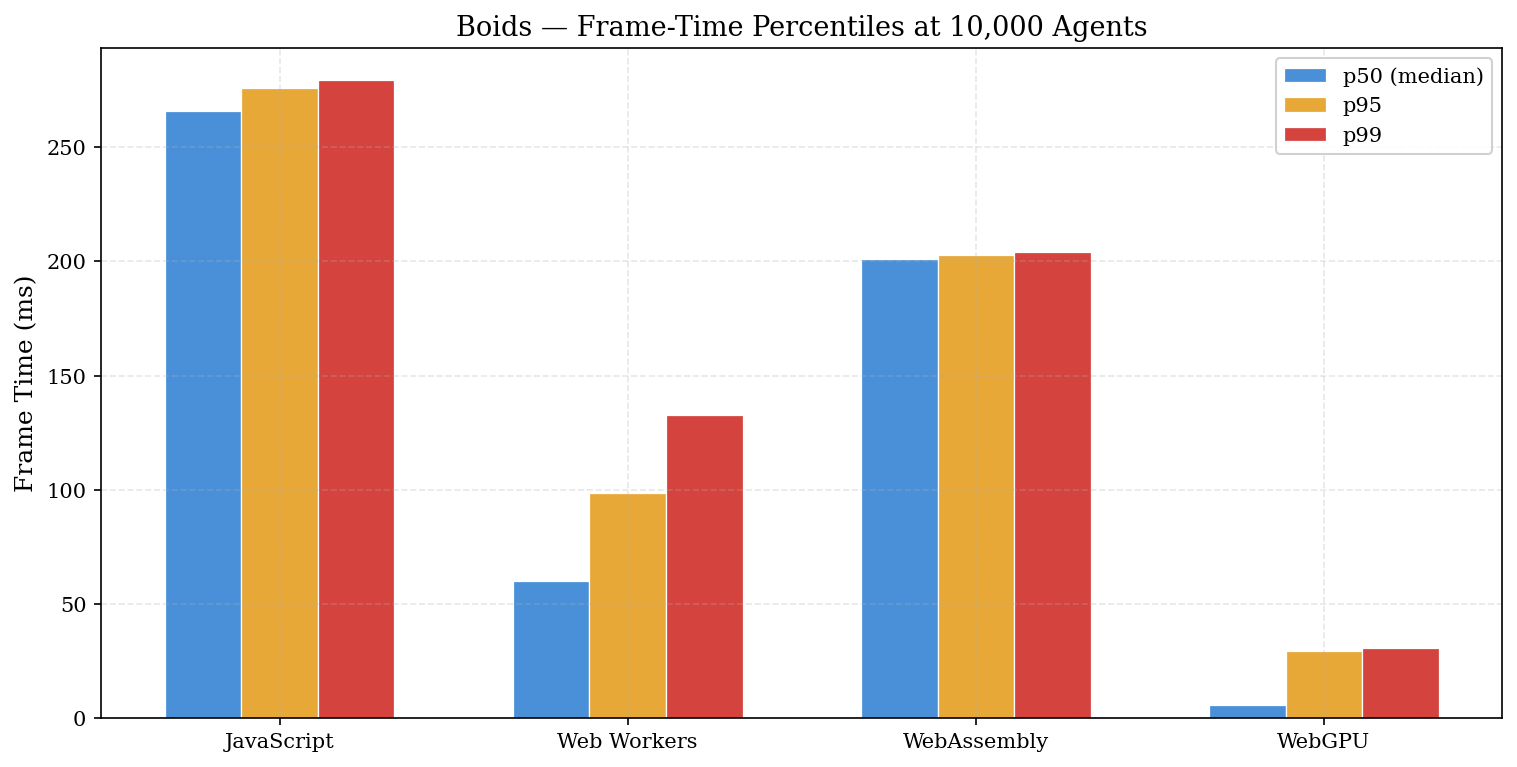

In [24]:
TAIL_AGENTS = 10000

tail_df = plot_df[plot_df["agentCount"] == TAIL_AGENTS].copy()
tail_df = tail_df.set_index("method").reindex(METHOD_ORDER).dropna(subset=["frameTime_p50"])

percentiles = ["frameTime_p50", "frameTime_p95", "frameTime_p99"]
pct_labels = ["p50 (median)", "p95", "p99"]
pct_colors = ["#4A90D9", "#E8A838", "#D5433E"]

x = np.arange(len(tail_df))
width = 0.22

fig, ax = plt.subplots(figsize=(10, 5))
for i, (col, label, color) in enumerate(zip(percentiles, pct_labels, pct_colors)):
    ax.bar(x + i * width, tail_df[col].values, width,
           label=label, color=color, edgecolor="white", linewidth=0.6)

ax.set_xticks(x + width)
ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in tail_df.index])
ax.set_ylabel("Frame Time (ms)")
ax.set_title(f"Boids — Frame-Time Percentiles at {TAIL_AGENTS:,} Agents")
ax.legend()

save_figure(fig, "boids_frame_time_percentiles")

## 10 — Memory Footprint Scaling

Compare memory footprint estimates reported by each backend as agent count increases.

  ✓ Saved outputs/figures/boids_memory_footprint.png
  ✓ Saved outputs/figures/boids_memory_footprint.pdf


[PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_memory_footprint.png'),
 PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_memory_footprint.pdf')]

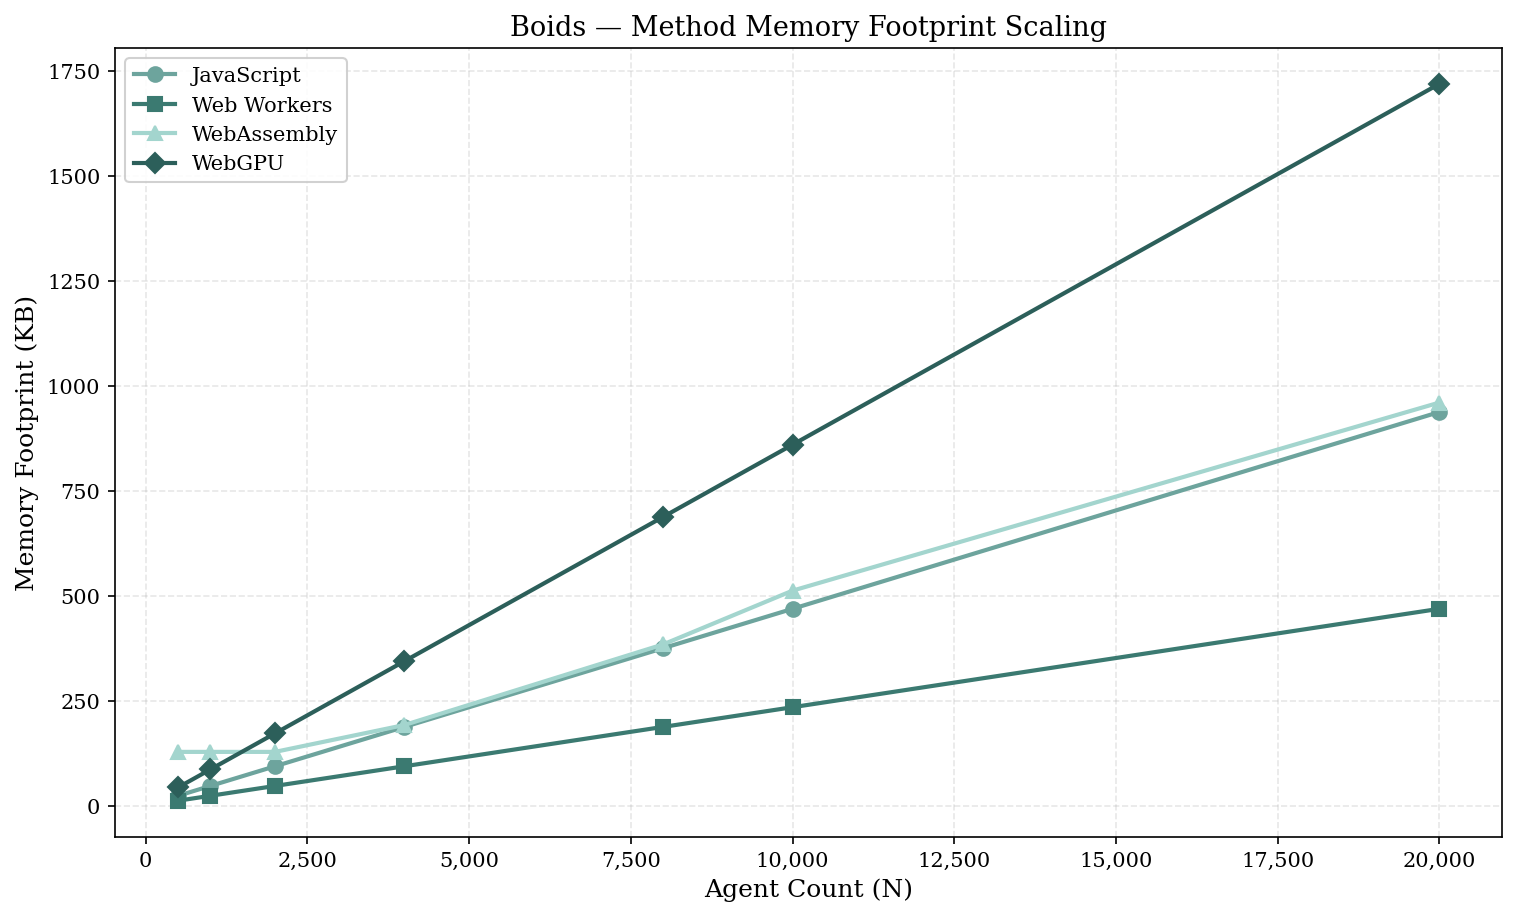

In [25]:
# Frame-level memory — aggregate mean per method/agentCount
mem_df = fdf.dropna(subset=["methodMemoryFootprintBytes"]).copy()
mem_df = mem_df[mem_df["renderMode"] == "cpu"]

# For WebWorkers keep best worker count, for WASM keep best mode
# (same logic as representative selection)
keep_indices = []
for method in METHOD_ORDER:
    m_df = mem_df[mem_df["method"] == method]
    if method == "WebWorkers":
        # Use best worker count (2 or 4 are typical sweet spot)
        best_wc = best_ww.set_index("agentCount")["workerCount"]
        for ac, wc in best_wc.items():
            keep_indices.extend(
                m_df[(m_df["agentCount"] == ac) & (m_df["workerCount"] == wc)].index.tolist()
            )
    elif method == "WebAssembly":
        best_wm = best_wa.set_index("agentCount")["wasmExecutionMode"]
        for ac, wm in best_wm.items():
            keep_indices.extend(
                m_df[(m_df["agentCount"] == ac) & (m_df["wasmExecutionMode"] == wm)].index.tolist()
            )
    else:
        keep_indices.extend(m_df.index.tolist())

mem_repr = mem_df.loc[keep_indices]
mem_agg = mem_repr.groupby(["method", "agentCount"])["methodMemoryFootprintBytes"].mean().reset_index()
mem_agg["memoryKB"] = mem_agg["methodMemoryFootprintBytes"] / 1024

fig, ax = plt.subplots(figsize=(10, 6))
for method in METHOD_ORDER:
    subset = mem_agg[mem_agg["method"] == method].sort_values("agentCount")
    if subset.empty:
        continue
    ax.plot(
        subset["agentCount"],
        subset["memoryKB"],
        marker=markers.get(method, "o"),
        color=get_method_color(method),
        label=METHOD_LABELS.get(method, method),
    )

ax.set_xlabel("Agent Count (N)")
ax.set_ylabel("Memory Footprint (KB)")
ax.set_title("Boids — Method Memory Footprint Scaling")
ax.legend()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

save_figure(fig, "boids_memory_footprint")

## 11 — WebGPU: CPU-Render vs. GPU-Render

Compare WebGPU total frame time between CPU-side rendering and full GPU rendering to quantify the render-path advantage.

  ✓ Saved outputs/figures/boids_webgpu_cpu_vs_gpu_render.png
  ✓ Saved outputs/figures/boids_webgpu_cpu_vs_gpu_render.pdf


[PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_webgpu_cpu_vs_gpu_render.png'),
 PosixPath('/Users/morgandaniel/Documents/dissertation/benchmark-analysis/outputs/figures/boids_webgpu_cpu_vs_gpu_render.pdf')]

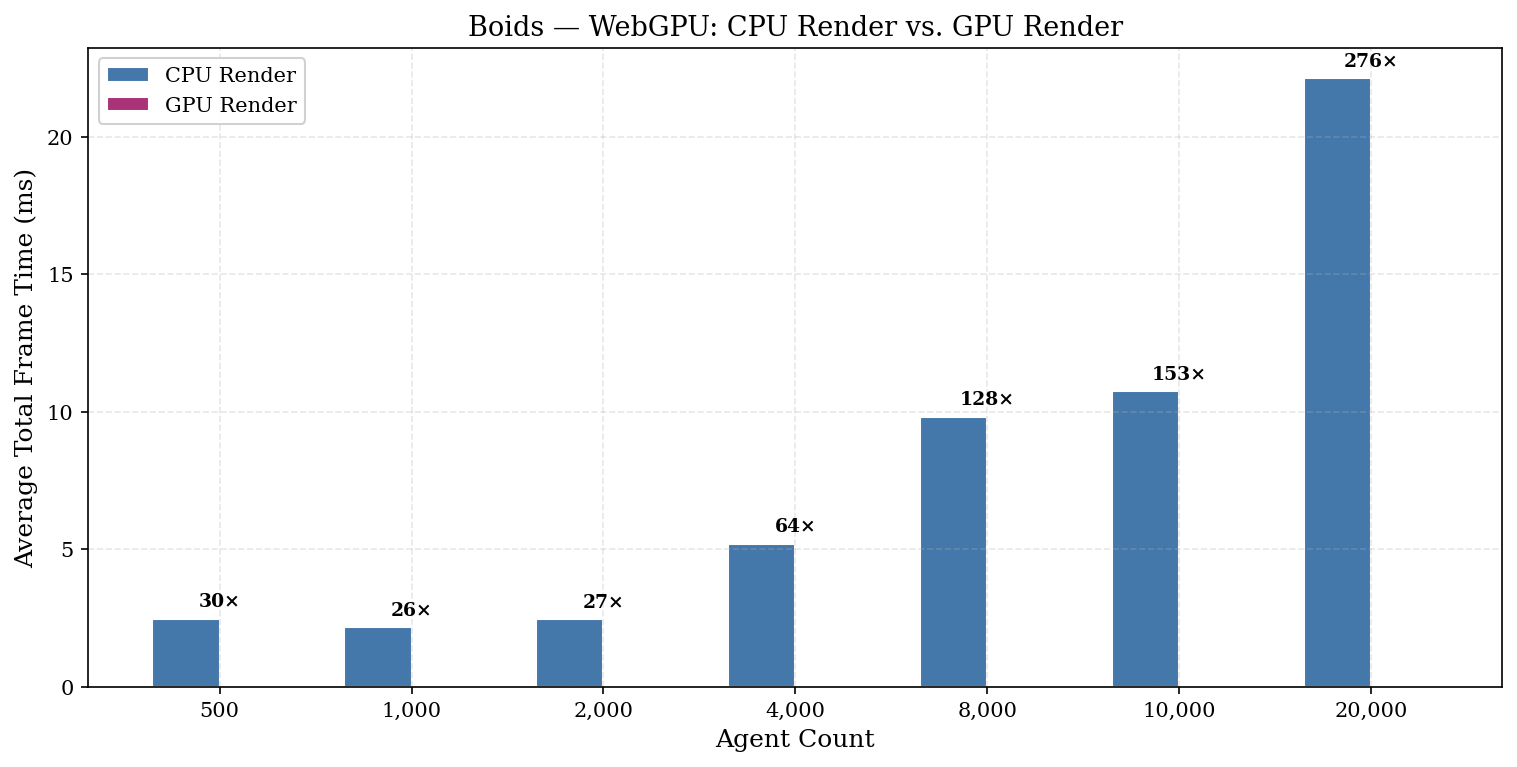

In [26]:
gpu_all = df[df["method"] == "WebGPU"].copy()
gpu_cpu_render = gpu_all[gpu_all["renderMode"] == "cpu"].sort_values("agentCount")
gpu_gpu_render = gpu_all[gpu_all["renderMode"] == "gpu"].sort_values("agentCount")

agent_counts = sorted(gpu_all["agentCount"].unique())
x = np.arange(len(agent_counts))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, gpu_cpu_render["avgTotalTime"].values, width,
       label="CPU Render", color="#4477AA", edgecolor="white")
ax.bar(x + width / 2, gpu_gpu_render["avgTotalTime"].values, width,
       label="GPU Render", color="#AA3377", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"{int(a):,}" for a in agent_counts])
ax.set_xlabel("Agent Count")
ax.set_ylabel("Average Total Frame Time (ms)")
ax.set_title("Boids — WebGPU: CPU Render vs. GPU Render")
ax.legend()

# Annotate speedup
for i, (cpu_val, gpu_val) in enumerate(zip(
    gpu_cpu_render["avgTotalTime"].values, gpu_gpu_render["avgTotalTime"].values
)):
    speedup = cpu_val / gpu_val if gpu_val > 0 else float("inf")
    ax.text(x[i], max(cpu_val, gpu_val) + 0.3, f"{speedup:.0f}×",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

save_figure(fig, "boids_webgpu_cpu_vs_gpu_render")